In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Target classes:", data.target_names)
print("Shape of data:", X.shape)

Target classes: ['malignant' 'benign']
Shape of data: (569, 30)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC AUC
y_probs = logreg.predict_proba(X_test_scaled)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_probs))

Accuracy: 0.9736842105263158
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[41  2]
 [ 1 70]]
ROC AUC Score: 0.99737962659679


In [7]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']  # solver that supports both L1 and L2
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# Predict using best model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("Best Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC AUC of Best Model:", roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1]))

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.9912280701754386
ROC AUC of Best Model: 0.998689813298395


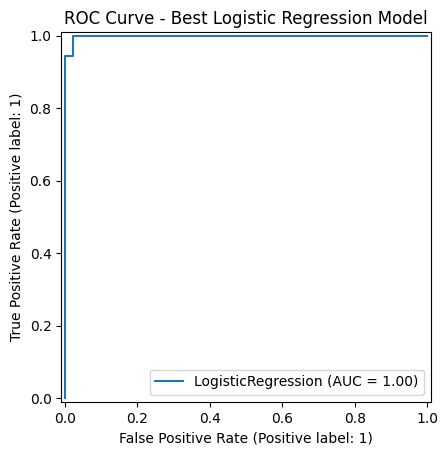

In [8]:
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
plt.title("ROC Curve - Best Logistic Regression Model")
plt.show()

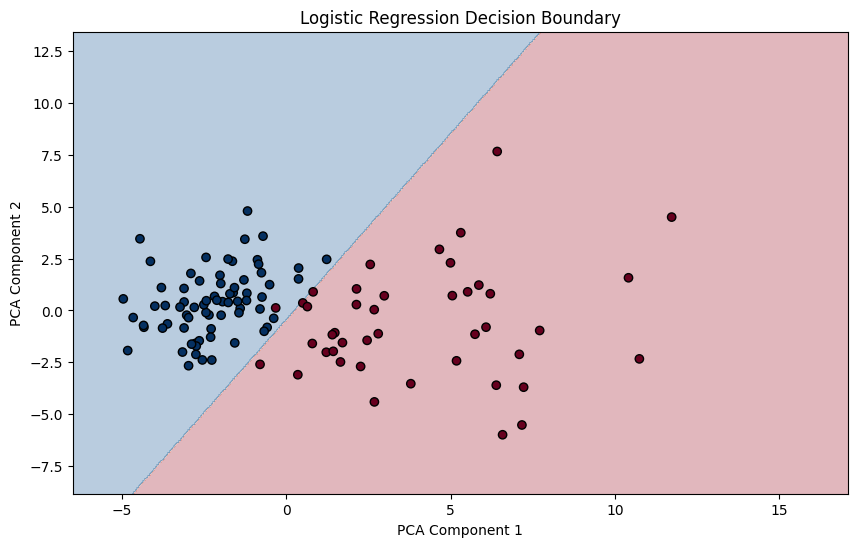

In [9]:
from sklearn.decomposition import PCA

# Reduce features to 2D for visualization
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train_scaled)
X_test_2D = pca.transform(X_test_scaled)

# Train a new model on 2D data
log_reg_vis = LogisticRegression()
log_reg_vis.fit(X_train_2D, y_train)

# Create a meshgrid to plot decision boundary
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict over meshgrid
Z = log_reg_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, cmap='RdBu', edgecolor='k')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

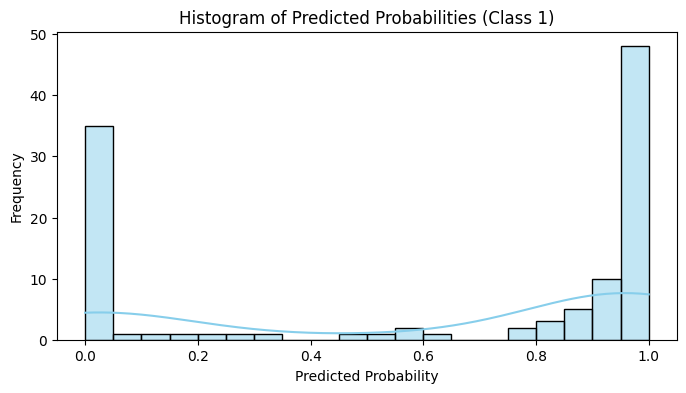

In [10]:
# Predict probabilities
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(8, 4))
sns.histplot(y_prob, bins=20, kde=True, color='skyblue')
plt.title("Histogram of Predicted Probabilities (Class 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()
